# 03 — Variant 3: Pix2Pix + VGG perceptual loss

Adds a VGG-19 feature-space loss (`relu_1_2`, `relu_2_2`, `relu_3_3`)
to the Pix2Pix objective for higher perceptual quality.

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import AnimeColorizationDataset
from src.training import Pix2PixTrainer
from src.utils import seed_everything, plot_loss_curves, qualitative_grid, evaluate_model

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")
CKPT_DIR = Path("../checkpoints/03_pix2pix_perceptual")
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

CONFIG = dict(
    image_size=256,
    batch_size=16,
    num_workers=8,
    epochs=50,
    lr=2e-4,
    lambda_l1=100.0,
    lambda_gan=1.0,
    lambda_perceptual=10.0,
)

## Data

AnimeColorizationDatasets + paired DataLoaders for every split (train, val, test).

In [2]:
splits = {split: AnimeColorizationDataset(DATA_ROOT, split=split,
                                          image_size=CONFIG["image_size"])
          for split in ("train", "val", "test")}

train_loader = DataLoader(splits["train"], batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=CONFIG["num_workers"],
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = DataLoader(splits["val"], batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"],
                        pin_memory=True, persistent_workers=True)
test_loader = DataLoader(splits["test"], batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"],
                         pin_memory=True, persistent_workers=True)

for split, ds in splits.items():
    print(f"{split:5s}: {len(ds):6d} images")

train:  14224 images
val  :   1772 images
test :   1773 images


## Training

`Pix2PixTrainer` with `lambda_perceptual=10`: U-Net generator + PatchGAN discriminator + L1 + VGG-19 perceptual loss (`relu_1_2`, `relu_2_2`, `relu_3_3`). Best checkpoint selected by `val_l1`. Resume by uncommenting `load_checkpoint`.

In [3]:
trainer = Pix2PixTrainer(
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_dir=CKPT_DIR,
    lr=CONFIG["lr"],
    lambda_l1=CONFIG["lambda_l1"],
    lambda_gan=CONFIG["lambda_gan"],
    lambda_perceptual=CONFIG["lambda_perceptual"],
)

# To resume an interrupted run, uncomment:
# trainer.load_checkpoint("last.pt")

history = trainer.fit(CONFIG["epochs"])

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/mmondo/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:04<00:00, 117MB/s]  


epoch   1/50 | train_d=0.2849 | train_l1=0.2048 | train_gan=2.5769 | train_perceptual=1.9005 | train_g=42.0615 | val_l1=0.1838


epoch   2/50 | train_d=0.2209 | train_l1=0.1692 | train_gan=3.4733 | train_perceptual=1.7275 | train_g=37.6698 | val_l1=0.1646


epoch   3/50 | train_d=0.2117 | train_l1=0.1606 | train_gan=3.6182 | train_perceptual=1.6856 | train_g=36.5313 | val_l1=0.1576


epoch   4/50 | train_d=0.2189 | train_l1=0.1552 | train_gan=3.7220 | train_perceptual=1.6733 | train_g=35.9749 | val_l1=0.1571


...

epoch  46/50 | train_d=0.2051 | train_l1=0.0767 | train_gan=3.4832 | train_perceptual=1.4468 | train_g=25.6174 | val_l1=0.1489


epoch  47/50 | train_d=0.2126 | train_l1=0.0761 | train_gan=3.4951 | train_perceptual=1.4423 | train_g=25.5301 | val_l1=0.1504


epoch  48/50 | train_d=0.2302 | train_l1=0.0756 | train_gan=3.4585 | train_perceptual=1.4379 | train_g=25.3993 | val_l1=0.1486


epoch  49/50 | train_d=0.2057 | train_l1=0.0752 | train_gan=3.5387 | train_perceptual=1.4347 | train_g=25.4068 | val_l1=0.1494


epoch  50/50 | train_d=0.2411 | train_l1=0.0746 | train_gan=3.3619 | train_perceptual=1.4288 | train_g=25.1057 | val_l1=0.1488


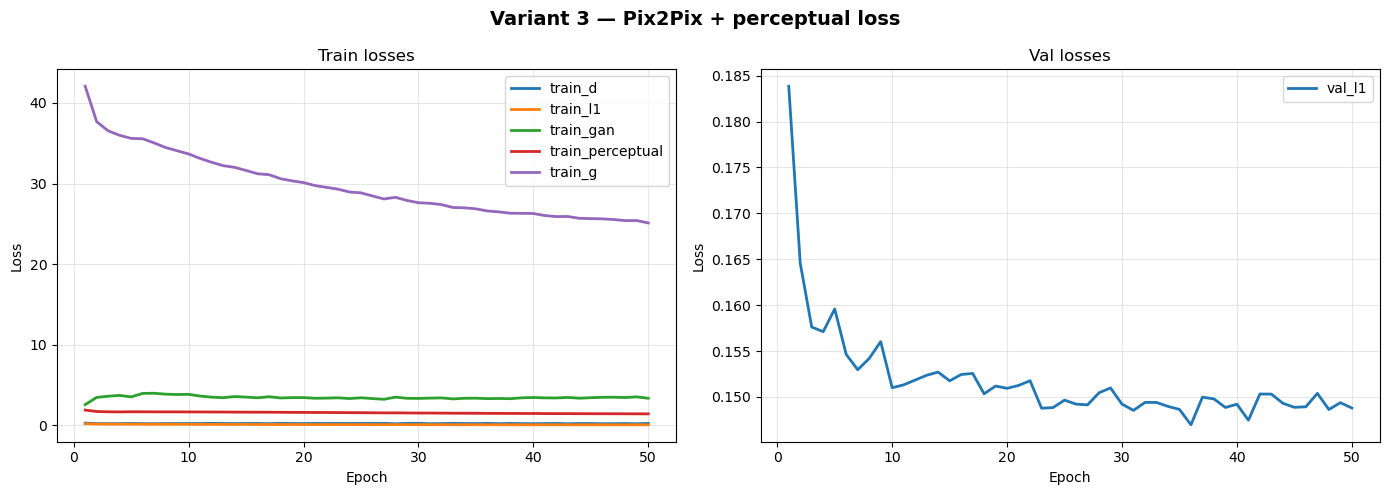

In [4]:
trainer.load_checkpoint("last.pt")
plot_loss_curves(trainer.history, title="Variant 3 — Pix2Pix + perceptual loss",
                 save_path=FIG_DIR / "03_pix2pix_perceptual_losses.png")

## Qualitative results

Best checkpoint (lowest `val_l1`), random test batch: sketch | prediction | ground truth. Expect finer texture and color fidelity compared to Variant 2 thanks to the VGG feature-space supervision.

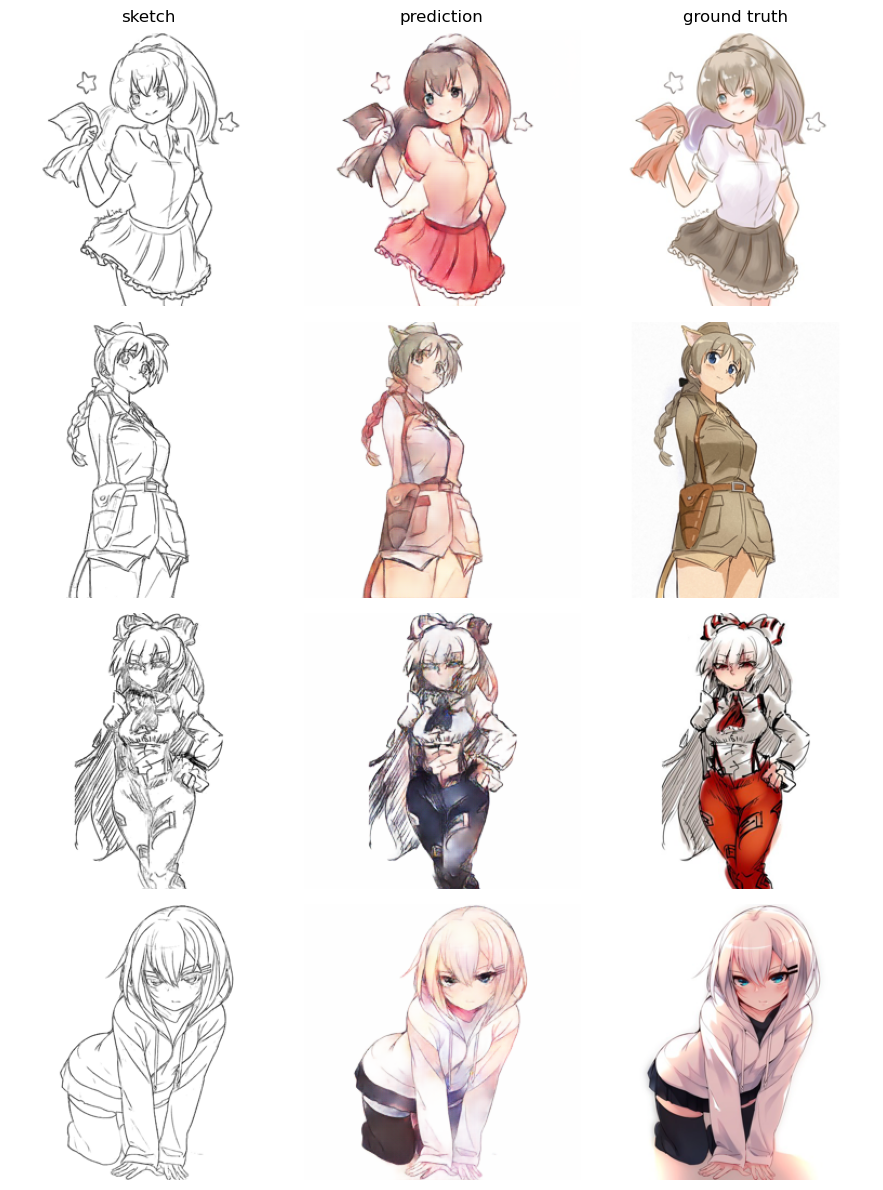

In [5]:
trainer.load_checkpoint("best.pt")

batch = next(iter(test_loader))
prediction = trainer.generate(batch["sketch"])
qualitative_grid(batch["sketch"], prediction, batch["color"], n_rows=4,
                 save_path=FIG_DIR / "03_pix2pix_perceptual_grid.png")

## Quantitative evaluation (test set)

PSNR / SSIM / LPIPS / FID on the full test split, saved to `results/tables/03_pix2pix_perceptual.json`.

In [6]:
metrics = evaluate_model(trainer.generator, test_loader,
                         fid_dir="../results/fid/03_pix2pix_perceptual")
print(metrics)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
with open(TABLE_DIR / "03_pix2pix_perceptual.json", "w") as f:
    json.dump({"variant": "03_pix2pix_perceptual", "config": CONFIG, "metrics": metrics}, f, indent=2)

/home/mmondo/miniconda3/envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.l

{'psnr': 16.285198211669922, 'ssim': 0.813014030456543, 'lpips': 0.1857001781463623, 'fid': np.float64(37.25303052095114)}
